# Notebook 5: Pharmacophore searching

In the previous notebooks you built a focussed database of putative MDM2 binders using *ligand-based* methods: fingerprints, similarity searching and machine-learning models. All of these methods describe a molecule by its **2D topology**. In this notebook you will add a complementary, **three-dimensional** and **structure-based** method to your toolbox: the **pharmacophore search**.

The idea is simple. The crystal structure of the MDM2-p53 complex tells us *which chemical groups* p53 places *at which positions in space* in order to bind MDM2. If we translate those requirements into an abstract 3D model - a **pharmacophore** - we can ask of every compound in our database: *can this molecule, in any of its conformations, place the same kind of chemical groups at the same positions?*

## Prepare yourself:

Two short and very readable reviews, to be read before the class:

- <a href="assets/pdf/notebook-5-paper-1.pdf" download>Yang, S.-Y. (2010) Pharmacophore modeling and applications in drug discovery: challenges and recent advances. *Drug Discov. Today* **15**, 444-450.</a> [pdf]
- <a href="assets/pdf/notebook-5-paper-2.pdf" download>Estrada-Ortiz, N.; Neochoritis, C.G.; Doemling, A. (2016) How to design a successful p53-MDM2/X interaction inhibitor: a thorough overview based on crystal structures. *ChemMedChem* **11**, 757-772.</a> [pdf]

## What you will learn

At the end of this notebook you should be able to explain:

1. what a pharmacophore is, and what the common feature types (lipophilic, aromatic, H-bond donor, H-bond acceptor, excluded volume) represent;
2. why a pharmacophore is a **3D** model and why that forces us to generate conformations;
3. how the p53-MDM2 interaction can be translated into a pharmacophore (the "three-finger" model);
4. how to **validate** a pharmacophore against known inhibitors, and what to do when the validation fails;
5. how to **screen** the compound database of notebook 4 with a pharmacophore, and how to rank and inspect the hits;
6. why a pharmacophore hit is a *hypothesis*, not a binder.

## Planning (approximately two hours)

| Section | Content | Time |
|---|---|---|
| 1-3 | Concepts: pharmacophores, the p53-MDM2 interaction, the three-finger model | 25 min |
| 4-7 | PyPharao, the MDM2 structure, building the pharmacophore | 30 min |
| 8-11 | Five known inhibitors: 3D conformers and validation | 30 min |
| 12-14 | Screening the notebook 4 database and analysing the hits | 30 min |
| 15-16 | Discussion and take-home messages | 10 min |

## 1. What is a pharmacophore?

The IUPAC glossary of medicinal chemistry (<a href="assets/pdf/notebook-5-paper-3.pdf" download>Wermuth *et al.*, 1998</a>) defines a pharmacophore as the ensemble of steric and electronic features that a molecule needs in order to make the optimal interactions with a given target, and so to trigger or block its biological response. Note what the definition does *not* say: it says nothing about atoms, bonds or a particular chemical series.

Two things in it are essential.

First, a pharmacophore describes **features, not atoms**. A feature is an abstraction of a chemical property: "something lipophilic", "an aromatic ring", "an H-bond donor". A phenyl, a thiophene and a pyridine ring are chemically different, but all three can satisfy the same *aromatic* feature. This is exactly why pharmacophores are able to jump between chemical series - something a fingerprint similarity search (notebook 3) can never do, because a fingerprint only recognises substructures it has already seen.

Second, a pharmacophore is an **arrangement in space**. It is not a list of features but a list of features *at positions*, i.e. a geometry. A molecule only matches if it can present the right features at the right mutual distances, which means that a pharmacophore search is intrinsically three-dimensional and conformation-dependent.

The feature types used in practice are few:

| Feature | Abbreviation | What it represents |
|---|---|---|
| Lipophilic / hydrophobic | `LIPO` | an apolar, solvent-shielded group (alkyl, halogen, apolar ring) making van der Waals contacts |
| Aromatic | `AROM` | the centroid of an aromatic ring, with the ring *plane normal* as a direction - it can also make pi-stacking and pi-cation interactions |
| H-bond donor | `HDON` | an N-H or O-H that donates a hydrogen bond |
| H-bond acceptor | `HACC` | an N or O lone pair that accepts a hydrogen bond |
| Positive / negative charge | `POSC` / `NEGC` | an ionisable group making an electrostatic interaction |
| Excluded volume | `EXCL` | a position that is *occupied by the protein*, so a ligand atom may not be there |

Excluded volumes are the mirror image of the other features: the ordinary features say "put something **here**", excluded volumes say "put nothing **here**". Together they encode both the chemistry and the shape of the binding site.

**Question 1.** A fingerprint similarity search and a pharmacophore search can both be used for virtual screening. Why can a pharmacophore search in principle find a completely new chemical scaffold, while a similarity search cannot?

## 2. The p53-MDM2 interaction

In notebook 1 you looked at PDB entry <a href="https://www.rcsb.org/structure/1YCR" target="_blank">1YCR</a>, the 2.6 A structure of the N-terminal domain of MDM2 in complex with a 15-residue peptide from the p53 transactivation domain (<a href="assets/pdf/notebook-5-paper-4.pdf" download>Kussie *et al.*, 1996</a>). What that paper reports is the following. MDM2 offers a deep, largely apolar cleft; the p53 fragment folds into an amphipathic alpha-helix and lays its hydrophobic face into that cleft; and the recognition is dominated by shape complementarity plus **three p53 side chains - Phe19, Trp23 and Leu26 - which reach furthest into the cleft**. Those three side chains are the "hot spots" of the interaction, and the same three residues are the ones p53 needs for transactivation.

Three hydrophobic side chains inserting into three subpockets: that is a remarkably simple recognition motif for a protein-protein interaction, and it is the reason why this particular PPI became druggable. The medicinal-chemistry literature therefore refers to the **"three-finger pharmacophore"** of MDM2 inhibitors: a successful small molecule has to put three hydrophobic groups into the Phe19, Trp23 and Leu26 subpockets (see for example Angulo *et al.*, 2016, who confirmed this requirement experimentally by STD NMR).

Besides the three hydrophobic contacts there is one well-defined polar interaction: the **indole N-H of Trp23 donates a hydrogen bond to the backbone carbonyl oxygen of Leu54 of MDM2**. We will verify this distance ourselves in a moment.

**Question 2.** Phe19, Trp23 and Leu26 are all described as "hydrophobic". Which pharmacophore feature type from the table above would you assign to each of them? Is there a residue for which more than one feature type is defensible?

## 3. Software: PyPharao

We will use **PyPharao**, the Python implementation of the **Pharao** algorithm that was published by Taminau, Thijs and De Winter (2008). You can find it at <a href="https://github.com/silicos-it/PyPharao" target="_blank">https://github.com/silicos-it/PyPharao</a>.

Two ideas are enough to understand what PyPharao does:

1. **Feature perception with RDKit.** Given a 3D molecule, PyPharao assigns pharmacophore features (`AROM`, `LIPO`, `HDON`, `HACC`, ...) to the relevant atoms and ring centroids, using RDKit for the underlying chemistry.
2. **Gaussian volume alignment.** Every feature is represented not as a point but as a **Gaussian sphere** with a width *sigma*. Two features of compatible type that sit close together have a large Gaussian **overlap volume**; the further apart they are, the smaller the overlap. PyPharao rigidly rotates and translates each database conformation so that this total overlap volume with the query pharmacophore is maximal, and then reports the remaining overlap as a score.

The advantage of the Gaussian formulation is that the score is a smooth, continuous number instead of a yes/no answer: a molecule that places its features *almost* right still gets a reasonable score, and the hits can be **ranked**.

The scores PyPharao reports are built from three volumes: the self-overlap of the query (`ref_volume`), the self-overlap of the molecule (`db_volume`) and the overlap after alignment (`overlap_volume`). From these it computes

- `tanimoto` = overlap / (ref + db - overlap), which punishes a molecule for features it has *in addition* to the query;
- `tversky_ref` = overlap / ref, which only asks *how completely the query is satisfied*;
- `tversky_db` = overlap / db.

Our query will be a small 3-feature pharmacophore and our database molecules are drug-sized with 5-10 features each, so a complete match can never give a high Tanimoto. **We will therefore rank on `tversky_ref`**: "which fraction of my pharmacophore does this molecule reproduce?".

In [1]:
# Install the packages used in this notebook.
# PyPharao is installed straight from its GitHub repository.
!pip install rdkit py3Dmol pandas matplotlib tqdm
!pip install git+https://github.com/silicos-it/PyPharao.git

  Cloning https://github.com/silicos-it/PyPharao.git to /private/var/folders/y1/hjqj8gf97l5g_lc7n3nysbcc0000gn/T/pip-req-build-c016s7kx
  Running command git clone --filter=blob:none --quiet https://github.com/silicos-it/PyPharao.git /private/var/folders/y1/hjqj8gf97l5g_lc7n3nysbcc0000gn/T/pip-req-build-c016s7kx


  Resolved https://github.com/silicos-it/PyPharao.git to commit eb0a2a2417a380d676b9b4d7f0f88fc254c39807


  Installing build dependencies ... -

 \

 done


  Getting requirements to build wheel ... - done


  Preparing metadata (pyproject.toml) ... - done


In [2]:
# RDKit chemistry
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors

# RDKit drawing
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import rdDepictor
IPythonConsole.ipython_useSVG = True
rdDepictor.SetPreferCoordGen(True)

# Numerical work, tables and plots
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 3D visualisation in the notebook (as in notebook 1), downloads and file handling
import py3Dmol
import requests
import os
from tqdm.auto import tqdm

# PyPharao: the complete public API is available from the top of the package
import pypharao
from pypharao import *

# Files that are generated by this notebook are written to the "scratch" folder,
# which is not tracked by git
os.makedirs("scratch", exist_ok=True)

print("RDKit    :", Chem.rdBase.rdkitVersion)
print("PyPharao :", pypharao.__version__)

RDKit    : 2026.03.1
PyPharao : 1.0.2


Let us have a look at the features PyPharao is able to perceive automatically. A `QueryPharmacophorePerception` object controls which feature types are switched on when a pharmacophore is derived from a 3D structure:

In [3]:
perception = QueryPharmacophorePerception()
perception.print_features()

AROM        on   Aromatic ring centroids with plane normals
LIPO        on   Lipophilic regions (from molecular surface) but no aromatics
HDON        on   H-bond donors (N/O with H, not negatively charged)
HACC        on   H-bond acceptors (N/O, with Pharao-style filters)
HACC_AND_HDON  on   Both a HACC and a HDON
POSC        on   Positively charged atoms
NEGC        on   Negatively charged atoms


Note that `EXCL` (excluded volume) and the "either/or" query types are *not* in this list: they are never perceived automatically, but we can add them to a query ourselves. We will use both later on.

## 4. Loading the MDM2-p53 structure

We re-use the structure from notebook 1: **1YCR**. A copy is stored in the course repository, so the notebook also works without an internet connection. If the local copy is missing, it is downloaded once from the PDB and saved.

In [4]:
PDB_DIR = os.path.join("assets", "databases", "notebook-5")


def load_pdb(pdb_id):
    """Return the text of a PDB file, from the course repository or from the RCSB PDB.

    A structure that has to be downloaded is kept in the scratch folder, so that the
    download happens only once.
    """
    course_copy = os.path.join(PDB_DIR, f"{pdb_id}.pdb")
    if os.path.exists(course_copy):
        print(f"{pdb_id}: using the local copy in {PDB_DIR}")
        with open(course_copy) as f:
            return f.read()

    scratch_copy = f"scratch/{pdb_id}.pdb"
    if os.path.exists(scratch_copy):
        print(f"{pdb_id}: using the copy downloaded earlier, {scratch_copy}")
        with open(scratch_copy) as f:
            return f.read()

    print(f"{pdb_id}: downloading from the RCSB PDB")
    text = requests.get(f"https://files.rcsb.org/download/{pdb_id}.pdb").text
    with open(scratch_copy, "w") as f:
        f.write(text)
    return text


pdb_1ycr = load_pdb("1YCR")

# Chain A is MDM2, chain B is the p53 peptide
chains = {}
for line in pdb_1ycr.splitlines():
    if line.startswith("ATOM"):
        chains[line[21]] = chains.get(line[21], 0) + 1
print("atoms per chain:", chains)

1YCR: using the local copy in assets/databases/notebook-5
atoms per chain: {'A': 705, 'B': 113}


## 5. Inspecting the binding site

First have a good look at the pocket. MDM2 (chain A) is shown as a grey surface, the p53 helix (chain B) in red, and the three hot-spot side chains as sticks. Rotate the view and convince yourself that Phe19, Trp23 and Leu26 really do point *into* the protein while the rest of the helix stays at the surface.

In [5]:
view = py3Dmol.view(width=800, height=500)
view.addModel(pdb_1ycr, "pdb")

# MDM2 = chain A: cartoon plus a transparent molecular surface
view.setStyle({"chain": "A"}, {"cartoon": {"color": "lightgray"}})
view.addSurface(py3Dmol.VDW, {"opacity": 0.70, "color": "lightgray"}, {"chain": "A"})

# p53 = chain B: red helix with the three hot-spot residues as sticks
view.setStyle({"chain": "B"}, {"cartoon": {"color": "red"}})
view.addStyle({"chain": "B", "resi": [19, 23, 26]},
              {"stick": {"colorscheme": "redCarbon", "radius": 0.25}})

view.zoomTo({"chain": "B"})
view.setBackgroundColor("white")
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Before we abstract the interaction into features, let us check the one polar interaction mentioned above: the hydrogen bond between the indole N-H of p53 Trp23 and the backbone C=O of MDM2 Leu54.

In [6]:
def atom_coordinates(pdb_text, chain, resnum, atom_name):
    """Return the coordinates of one atom of a PDB file as a NumPy array."""
    for line in pdb_text.splitlines():
        if not line.startswith("ATOM"):
            continue
        if line[21] == chain and int(line[22:26]) == resnum and line[12:16].strip() == atom_name:
            return np.array([float(line[30:38]), float(line[38:46]), float(line[46:54])])
    return None


trp23_ne1 = atom_coordinates(pdb_1ycr, "B", 23, "NE1")   # indole N-H of p53 Trp23
leu54_o = atom_coordinates(pdb_1ycr, "A", 54, "O")       # backbone C=O of MDM2 Leu54

print("N(Trp23) ... O(Leu54) distance = %.2f A" % np.linalg.norm(trp23_ne1 - leu54_o))

N(Trp23) ... O(Leu54) distance = 2.83 A


A nitrogen-oxygen distance of less than 3 A is a clear hydrogen bond. So the Trp23 indole is doing two things at once: its ring system fills a hydrophobic subpocket, and its N-H donates a hydrogen bond. Keep that in mind - we will come back to it as an optional extra feature.

## 6. From binding-site interactions to pharmacophore features

How do we turn this into a pharmacophore? PyPharao offers the function `query_pharmacophore_from_protein()`, which takes **two** PDB files:

- a first file whose atoms are used to **perceive the features**;
- a second file whose atoms become **excluded volumes**.

That split is exactly what we need. We let PyPharao perceive the features on the *p53 hot-spot side chains* - because those atoms mark the positions where a ligand should place its own groups - and we let the *MDM2 atoms* define the excluded volume, because that space is occupied by the protein.

So we write two small PDB files. For Phe19 and Trp23 we keep the ring atoms (from CG outwards); for Leu26 we keep the whole isobutyl side chain, starting at CB.

In [7]:
# The side-chain atoms of the three p53 hot-spot residues
HOTSPOT_ATOMS = {
    19: ["CG", "CD1", "CD2", "CE1", "CE2", "CZ"],                         # Phe19: phenyl ring
    23: ["CG", "CD1", "NE1", "CE2", "CD2", "CE3", "CZ2", "CZ3", "CH2"],   # Trp23: indole
    26: ["CB", "CG", "CD1", "CD2"],                                       # Leu26: isobutyl
}

hotspot_lines = []   # p53 side-chain atoms -> features
protein_lines = []   # MDM2 atoms           -> excluded volumes

for line in pdb_1ycr.splitlines():
    if not line.startswith("ATOM"):
        continue
    chain = line[21]
    resnum = int(line[22:26])
    atom_name = line[12:16].strip()

    if chain == "A":
        protein_lines.append(line)
    elif chain == "B" and resnum in HOTSPOT_ATOMS and atom_name in HOTSPOT_ATOMS[resnum]:
        hotspot_lines.append(line)

with open("scratch/mdm2_p53_hotspots.pdb", "w") as f:
    f.write("\n".join(hotspot_lines) + "\nEND\n")
with open("scratch/mdm2_protein.pdb", "w") as f:
    f.write("\n".join(protein_lines) + "\nEND\n")

print(len(hotspot_lines), "hot-spot atoms written to scratch/mdm2_p53_hotspots.pdb")
print(len(protein_lines), "MDM2 atoms written to scratch/mdm2_protein.pdb")

19 hot-spot atoms written to scratch/mdm2_p53_hotspots.pdb
705 MDM2 atoms written to scratch/mdm2_protein.pdb


Now let PyPharao perceive the pharmacophore. The `min_distance_between_excl_points` argument thins out the excluded-volume spheres so that they are at least 1.5 A apart - without it we would get one sphere per protein atom, which is needlessly dense.

In [8]:
raw_pharmacophore = query_pharmacophore_from_protein(
    "scratch/mdm2_p53_hotspots.pdb",     # atoms used to perceive the features
    "scratch/mdm2_protein.pdb",          # atoms that become excluded volumes
    min_distance_between_excl_points=1.5,
    name="p53-hotspots-raw",
)

features = [p for p in raw_pharmacophore if p.type != PointType.EXCL]
exclusions = [p for p in raw_pharmacophore if p.type == PointType.EXCL]

print("Perceived features:")
for i, p in enumerate(features):
    x, y, z = p.center
    print(f"  {i}  {p.type.value:<6}  center = ({x:7.2f}, {y:7.2f}, {z:7.2f})   sigma = {p.sigma}")
print(f"\nand {len(exclusions)} EXCL spheres derived from the MDM2 atoms")

Perceived features:
  0  AROM    center = (  31.84,  -23.00,   -9.26)   sigma = 0.7
  1  AROM    center = (  27.31,  -20.94,   -7.63)   sigma = 0.7
  2  AROM    center = (  28.36,  -20.46,   -5.82)   sigma = 0.7
  3  HDON    center = (  26.66,  -20.00,   -7.89)   sigma = 1.0
  4  LIPO    center = (  23.85,  -23.11,   -3.95)   sigma = 0.7
  5  LIPO    center = (  25.64,  -24.06,   -3.19)   sigma = 0.7

and 428 EXCL spheres derived from the MDM2 atoms


Six features were perceived from three side chains. Let us identify them, because this is the step where chemistry becomes a model:

- **three `AROM` points**: one is the phenyl ring of Phe19, the other two are the five- and six-membered rings of the Trp23 indole (RDKit sees an indole as two aromatic rings);
- **one `HDON` point**: the indole N-H of Trp23, i.e. exactly the hydrogen bond to Leu54 that we measured above;
- **two `LIPO` points**: the branched methyl groups of the Leu26 side chain.

This raw model is a faithful description of what p53 does, but it is *not* a good query. It contains two aromatic points for one indole and two lipophilic points for one isobutyl group, so a molecule would have to reproduce internal details of the p53 side chains rather than the interaction pattern. We therefore reduce it to **one feature per finger**.

In [9]:
def feature_distance(p, q):
    """Distance (A) between the centres of two pharmacophore points."""
    return float(np.linalg.norm(np.array(p.center) - np.array(q.center)))


arom_points = [p for p in features if p.type == PointType.AROM]
lipo_points = [p for p in features if p.type == PointType.LIPO]
hdon_point = [p for p in features if p.type == PointType.HDON][0]      # the Trp23 indole N-H

# The aromatic point furthest away from the indole N-H is the Phe19 ring
phe19_point = max(arom_points, key=lambda p: feature_distance(p, hdon_point))

# Of the two indole rings, the six-membered (benzo) ring is the one further from the N-H;
# it is also the part that inserts deepest into the Trp23 subpocket
indole_rings = sorted((p for p in arom_points if p is not phe19_point),
                      key=lambda p: feature_distance(p, hdon_point))
trp23_point = indole_rings[-1]

# The two lipophilic points of Leu26 are replaced by a single point at their midpoint
leu26_center = tuple(np.mean([p.center for p in lipo_points], axis=0))

print("Phe19 ring centroid :", np.round(phe19_point.center, 2))
print("Trp23 benzo ring    :", np.round(trp23_point.center, 2))
print("Leu26 (merged LIPO) :", np.round(leu26_center, 2))

Phe19 ring centroid : [ 31.84 -23.    -9.26]
Trp23 benzo ring    : [ 28.36 -20.46  -5.82]
Leu26 (merged LIPO) : [ 24.75 -23.58  -3.57]


### Building the three-finger query

We now assemble the query pharmacophore. Three decisions have to be justified:

1. **Which features do we keep?** One per finger: Phe19, Trp23 and Leu26. These are the three positions that the crystal structure identifies as the hot spots, and the three positions that every known MDM2 inhibitor class has to occupy.

2. **Which feature type do we give them?** The hot spots are *hydrophobic pockets*. p53 happens to fill two of them with aromatic rings, but a ligand may fill them with an aromatic ring **or** with an aliphatic group - a chlorophenyl, a cyclohexyl and a neopentyl group are all acceptable to a hydrophobic pocket. PyPharao has a query-only feature type for exactly this situation: `AROM_OR_LIPO`, which matches an `AROM` **or** a `LIPO` feature of the database molecule. Using it instead of a strict `AROM` is the single most important design decision in this pharmacophore.

3. **What do we do with the hydrogen bond?** The Trp23 N-H...Leu54 interaction is real, but not every inhibitor class reproduces it. We leave it out of the core model and come back to it as an optional refinement.

An `AROM_OR_LIPO` point carries a ring-plane *normal*. The Phe19 and Trp23 points inherit a meaningful normal from their rings, but the merged Leu26 point has no ring and therefore no meaningful plane. We give it an arbitrary normal and switch the directional term off during the search (`use_direction=False`), so that the ring orientations are not used as a criterion. This makes the model more tolerant, which is appropriate for a 3-point hydrophobic query.

In [10]:
three_finger = QueryPharmacophore(name="MDM2-three-finger")

# Finger 1 and 2: the Phe19 and Trp23 rings, relaxed from AROM to AROM_OR_LIPO
three_finger.add_point(phe19_point.replace(type=PointType.AROM_OR_LIPO))
three_finger.add_point(trp23_point.replace(type=PointType.AROM_OR_LIPO))

# Finger 3: the merged Leu26 point. AROM_OR_LIPO requires a normal, so we supply an
# arbitrary one (1 A along z) and disable the directional term when searching.
three_finger.add_point(
    PharmacophorePoint(
        type=PointType.AROM_OR_LIPO,
        center=leu26_center,
        normal=tuple(np.array(leu26_center) + np.array([0.0, 0.0, 1.0])),
        sigma=DEFAULT_SIGMA[PointType.AROM_OR_LIPO],
    )
)

print(f"Query '{three_finger.get_name()}' with {len(three_finger)} features\n")
labels = ["Phe19", "Trp23", "Leu26"]
for label, p in zip(labels, three_finger):
    x, y, z = p.center
    print(f"  {label}  {p.type.value:<13} center = ({x:7.2f}, {y:7.2f}, {z:7.2f})  sigma = {p.sigma}")

# The geometry of the model: the mutual distances between the three fingers
print("\nDistances between the fingers:")
for i in range(len(three_finger)):
    for j in range(i + 1, len(three_finger)):
        d = feature_distance(three_finger[i], three_finger[j])
        print(f"  {labels[i]} - {labels[j]} : {d:.2f} A")

Query 'MDM2-three-finger' with 3 features

  Phe19  AROM_OR_LIPO  center = (  31.84,  -23.00,   -9.26)  sigma = 0.7
  Trp23  AROM_OR_LIPO  center = (  28.36,  -20.46,   -5.82)  sigma = 0.7
  Leu26  AROM_OR_LIPO  center = (  24.75,  -23.58,   -3.57)  sigma = 0.7

Distances between the fingers:
  Phe19 - Trp23 : 5.52 A
  Phe19 - Leu26 : 9.11 A
  Trp23 - Leu26 : 5.28 A


These three distances *are* the pharmacophore. A molecule matches if it can place three hydrophobic groups at mutual distances of roughly 5.3, 5.5 and 9.1 A - and nothing else about it matters.

**Question 3.** Explain in one sentence why this model cannot be evaluated on a SMILES string or a 2D structure.

### Visualising the pharmacophore in its pocket

PyPharao can write a pharmacophore as a PDB file of pseudo-atoms, which lets us display it in the same viewer and the same coordinate frame as the protein. The three orange spheres below are our features; the red sticks are the p53 side chains they were derived from.

In [11]:
three_finger.write_pdb("scratch/mdm2_three_finger.pdb")

view = py3Dmol.view(width=800, height=500)

# model 0: the 1YCR complex
view.addModel(pdb_1ycr, "pdb")
view.setStyle({"chain": "A"}, {"cartoon": {"color": "lightgray"}})
view.addSurface(py3Dmol.VDW, {"opacity": 0.55, "color": "lightgray"}, {"chain": "A"})
view.setStyle({"chain": "B"}, {"cartoon": {"color": "red"}})
view.addStyle({"chain": "B", "resi": [19, 23, 26]},
              {"stick": {"colorscheme": "redCarbon", "radius": 0.25}})

# model 1: the pharmacophore. The feature centres are carbon pseudo-atoms; the two
# hydrogens per feature are the tips that make the ring-plane normal visible.
with open("scratch/mdm2_three_finger.pdb") as f:
    view.addModel(f.read(), "pdb")
view.setStyle({"model": 1, "elem": "C"},
              {"sphere": {"radius": 1.4, "color": "orange", "opacity": 0.65}})

view.zoomTo({"model": 1})
view.setBackgroundColor("white")
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**Question 4.** The three spheres sit at the positions of p53 side-chain atoms, not at the centres of the MDM2 subpockets. Why could that be a problem for a ligand that is not a peptide? (Keep your answer in mind - the validation in the next section will give you the answer.)

## 7. Five known MDM2 inhibitors

A pharmacophore is a hypothesis and a hypothesis has to be tested. The standard test is **retrospective validation**: can the model retrieve molecules that are *known* to bind the target?

We use five inhibitors of the p53-MDM2 interaction. They were selected so that they are (i) experimentally validated MDM2 binders, (ii) from **five different chemical scaffolds**, and (iii) structurally characterised, so that the binding mode is not a matter of speculation.

| Compound | Scaffold class | Co-crystal structure | ChEMBL | Primary reference |
|---|---|---|---|---|
| **Nutlin-3a** | *cis*-imidazoline | <a href="https://www.rcsb.org/structure/4HG7" target="_blank">4HG7</a> (ligand `NUT`, 1.6 A) | CHEMBL191334 | Vassilev *et al.* 2004; Anil *et al.* 2013 |
| **SAR405838** | spiro-oxindole | <a href="https://www.rcsb.org/structure/5TRF" target="_blank">5TRF</a> (ligand `7HC`, 2.1 A) | CHEMBL2381408 | Wang *et al.* 2014 |
| **Siremadlin** (NVP-HDM201) | pyrrolo-imidazolone | <a href="https://www.rcsb.org/structure/5OC8" target="_blank">5OC8</a> (ligand `9QW`, 1.56 A) | CHEMBL3653256 | Jeay *et al.* 2018 |
| **NVP-CGM097** | dihydroisoquinolinone | <a href="https://www.rcsb.org/structure/4ZYF" target="_blank">4ZYF</a> (ligand `4T4`, 1.8 A) | CHEMBL3601398 | Holzer *et al.* 2015 |
| **Navtemadlin** (AMG 232) | piperidinone | series defined by <a href="https://www.rcsb.org/structure/4OAS" target="_blank">4OAS</a> / <a href="https://www.rcsb.org/structure/4ERF" target="_blank">4ERF</a> | CHEMBL3125702 | Sun *et al.* 2014 |

Four of the five compounds are present in the PDB as a bound ligand; for navtemadlin itself no public co-crystal structure exists, but the binding mode of its piperidinone series is defined by the entries listed. Nutlin-3a is the compound that opened the field; the other four reached clinical trials.

A practical remark on where the structures come from. For every compound the SMILES was taken from the **PDB chemical component** or from **ChEMBL** and cross-checked between the two by InChIKey. That check matters: for SAR405838 and CGM097 the PubChem entry carries a *different stereochemistry* from the PDB ligand and from ChEMBL. Since the stereocentres of these compounds are essential for binding, we use the PDB/ChEMBL structures.

Nutlin-3a    MW =  581.5   rotatable bonds =  6
SAR405838    MW =  562.5   rotatable bonds =  4
Siremadlin   MW =  555.4   rotatable bonds =  6
NVP-CGM097   MW =  659.3   rotatable bonds =  9
Navtemadlin  MW =  568.6   rotatable bonds =  9


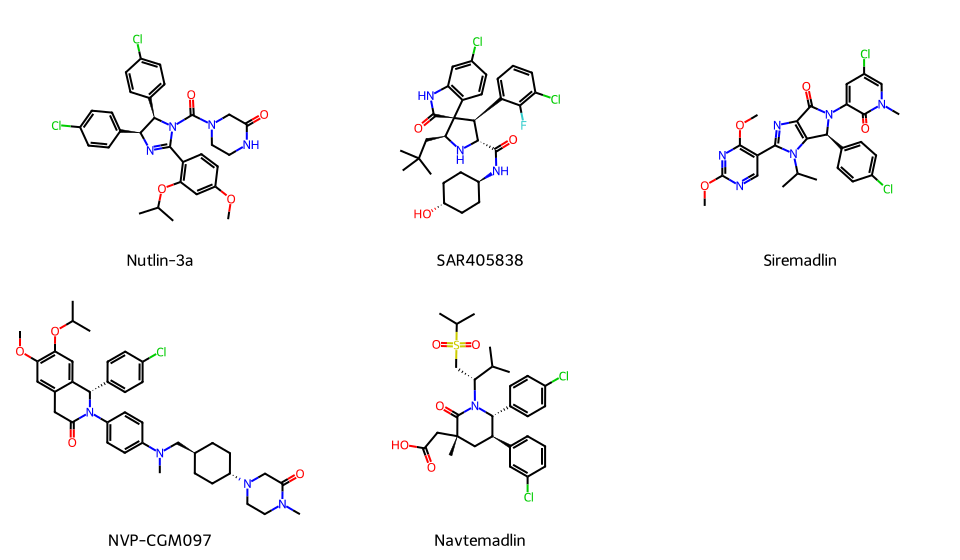

In [12]:
# SMILES from the PDB chemical component dictionary / ChEMBL, cross-checked by InChIKey.
INHIBITORS = {
    "Nutlin-3a": "COc1ccc(c(OC(C)C)c1)C2=N[C@H]([C@H](N2C(=O)N3CCNC(=O)C3)c4ccc(Cl)cc4)c5ccc(Cl)cc5",
    "SAR405838": "CC(C)(C)C[C@@H]1N[C@@H](C(=O)N[C@H]2CC[C@H](O)CC2)[C@H](c2cccc(Cl)c2F)[C@]12C(=O)Nc1cc(Cl)ccc12",
    "Siremadlin": "COc1ncc(c(OC)n1)c2nc3C(=O)N([C@@H](c4ccc(Cl)cc4)c3n2C(C)C)C5=CC(=CN(C)C5=O)Cl",
    "NVP-CGM097": "COc1cc2c(cc1OC(C)C)[C@H](c1ccc(Cl)cc1)N(c1ccc(N(C)C[C@H]3CC[C@H](N4CCN(C)C(=O)C4)CC3)cc1)C(=O)C2",
    "Navtemadlin": "CC(C)[C@@H](CS(=O)(=O)C(C)C)N1[C@@H]([C@H](C[C@](C1=O)(C)CC(=O)O)C2=CC(=CC=C2)Cl)C3=CC=C(C=C3)Cl",
}

# Parse and show them. Note the structural diversity of the five scaffolds.
inhibitor_mols_2d = []
for name, smiles in INHIBITORS.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print("could not parse the SMILES of", name)
        continue
    inhibitor_mols_2d.append(mol)
    print(f"{name:12s} MW = {Descriptors.MolWt(mol):6.1f}   rotatable bonds = {Descriptors.NumRotatableBonds(mol):2d}")

Draw.MolsToGridImage(inhibitor_mols_2d, legends=list(INHIBITORS.keys()), molsPerRow=3,
                     subImgSize=(320, 280))

**Question 5.** Pick two of these five molecules and identify, by eye, the three groups that could fill the three hydrophobic fingers. For which of the five is this hardest? (The co-crystal structures in the table let you check your answer afterwards.)

## 8. Generating 3D conformations

A pharmacophore search needs 3D coordinates, and a flexible molecule has many shapes. We do not know beforehand which conformation the compound adopts when bound, so we generate an ensemble of plausible conformations and let the search pick the best one per molecule.

We use RDKit's ETKDGv3 distance-geometry embedding followed by MMFF minimisation, as in notebook 4, but now with **many conformers per molecule**. The random seed is fixed so that everybody in the class gets the same numbers.

In [13]:
N_CONFORMERS = 50       # conformations per validation compound
RANDOM_SEED = 42         # for reproducibility


def generate_conformers(mol, n_conformers, seed):
    """Add explicit hydrogens, embed n conformers and minimise them with MMFF.

    Returns the molecule with conformers, or None when the embedding fails.
    """
    mol = Chem.AddHs(mol)
    params = AllChem.ETKDGv3()
    params.randomSeed = seed
    params.numThreads = 0                       # use all available cores
    conformer_ids = AllChem.EmbedMultipleConfs(mol, numConfs=n_conformers, params=params)
    if len(conformer_ids) == 0:
        return None
    AllChem.MMFFOptimizeMoleculeConfs(mol, numThreads=0)
    return mol


inhibitor_mols = []
inhibitor_names = []
for name, smiles in INHIBITORS.items():
    mol = Chem.MolFromSmiles(smiles)
    mol_3d = generate_conformers(mol, N_CONFORMERS, RANDOM_SEED)
    if mol_3d is None:
        print(f"{name}: conformer generation failed - compound skipped")
        continue
    mol_3d.SetProp("_Name", name)
    inhibitor_mols.append(mol_3d)
    inhibitor_names.append(name)
    print(f"{name:12s} {mol_3d.GetNumConformers():3d} conformers")

Nutlin-3a     50 conformers


SAR405838     50 conformers


Siremadlin    50 conformers


NVP-CGM097    50 conformers


Navtemadlin   50 conformers


## 9. Validating the pharmacophore

Now we screen the five known inhibitors against our query. A `PharmacophoreSearch` object is created from the query and a few settings:

- `use_direction=False`: do not use the ring-plane normals (see the discussion above);
- `epsilon=0.5` (the default): how closely the *distances* between a pair of molecule features must reproduce the corresponding distance in the query before that pairing is even considered. A **higher** epsilon is **stricter**;
- `min_matches`: how many query features must be matched. The default (`0`) means *all* of them - here all three fingers.

and `screen()` is given the molecules, with `keep="best"` and `metric="tversky_ref"` so that we get the best conformation per molecule.

In [14]:
def validate(query, molecules, names, *, epsilon=0.5, min_matches=0, use_direction=False):
    """Screen the validation compounds and return a tidy DataFrame of the results."""
    searcher = PharmacophoreSearch(query, use_direction=use_direction, epsilon=epsilon)
    hits = searcher.screen(
        molecules,
        conformations="all",      # consider every conformer we generated
        keep="best",              # report only the best conformer per molecule
        metric="tversky_ref",     # ... and judge "best" by tversky_ref
        min_matches=min_matches,
        progress=False,
    )

    rows = []
    for index, result in hits:
        rows.append({
            "compound": names[index],
            "features matched": len(result.mapping),
            "tversky_ref": round(result.tversky_ref, 3),
            "tanimoto": round(result.tanimoto, 3),
            "conformer": result.conf_id,
        })
    found = {row["compound"] for row in rows}
    for name in names:
        if name not in found:
            rows.append({"compound": name, "features matched": 0,
                         "tversky_ref": np.nan, "tanimoto": np.nan, "conformer": None})

    df = pd.DataFrame(rows).sort_values("tversky_ref", ascending=False, na_position="last")
    return df.reset_index(drop=True)


validation_strict = validate(three_finger, inhibitor_mols, inhibitor_names)
print("Strict model: all three fingers required, default distance tolerance\n")
validation_strict

Strict model: all three fingers required, default distance tolerance



,compound,features matched,tversky_ref,tanimoto,conformer
0,SAR405838,3,0.974,0.443,40.0
1,NVP-CGM097,3,0.945,0.531,37.0
2,Nutlin-3a,0,NaN,NaN,NaN
3,Siremadlin,0,NaN,NaN,NaN
4,Navtemadlin,0,NaN,NaN,NaN


### The validation fails - and that is instructive

Only two of the five known inhibitors are retrieved. A model that misses 60% of the known actives would be useless for prospective screening, so we have to understand *why* it fails. There are three candidate explanations, and they are the three classic failure modes of pharmacophore models.

**(a) The geometry was taken from a peptide.** Our distances come from the positions of p53 *side-chain* atoms. A small molecule occupies the same pockets, but it hangs its substituents on a rigid central scaffold and cannot necessarily reach exactly those three points. We can check this directly, because the PDB contains the co-crystal structure of nutlin-3a with MDM2 (4HG7): we can measure the mutual distances of the three aromatic rings *in the bound conformation* and compare them with our query.

In [15]:
# Extract the nutlin-3a ligand (residue NUT) from 4HG7 and perceive its pharmacophore
pdb_4hg7 = load_pdb("4HG7")
ligand_lines = [l for l in pdb_4hg7.splitlines() if l.startswith("HETATM") and l[17:20] == "NUT"]

ligand = Chem.MolFromPDBBlock("\n".join(ligand_lines) + "\nEND\n", sanitize=False, removeHs=False)
# A PDB file has no bond orders; take them from the SMILES of nutlin-3a
ligand = AllChem.AssignBondOrdersFromTemplate(Chem.MolFromSmiles(INHIBITORS["Nutlin-3a"]), ligand)
Chem.SanitizeMol(ligand)
ligand = Chem.AddHs(ligand, addCoords=True)

nutlin_pharmacophore = query_pharmacophore_from_molecule(ligand, name="nutlin-3a-crystal")
nutlin_rings = [p for p in nutlin_pharmacophore if p.type == PointType.AROM]

print("Nutlin-3a in its crystallographic binding mode (4HG7):")
print(f"  {len(nutlin_rings)} aromatic rings, mutual distances:")
crystal_distances = sorted(feature_distance(nutlin_rings[i], nutlin_rings[j])
                           for i in range(len(nutlin_rings)) for j in range(i + 1, len(nutlin_rings)))
print("  ", [round(d, 2) for d in crystal_distances], "A")

query_distances = sorted(feature_distance(three_finger[i], three_finger[j])
                         for i in range(len(three_finger)) for j in range(i + 1, len(three_finger)))
print("\nOur p53-derived query, mutual distances:")
print("  ", [round(d, 2) for d in query_distances], "A")

4HG7: using the local copy in assets/databases/notebook-5
Nutlin-3a in its crystallographic binding mode (4HG7):
  3 aromatic rings, mutual distances:
   [3.86, 6.79, 7.28] A

Our p53-derived query, mutual distances:
   [5.28, 5.52, 9.11] A


[15:59:38] WARNING: More than one matching pattern found - picking one



The two triangles are clearly different: the ligand's three rings span roughly 4-7 A, while the p53 side chains span 5-9 A. An inhibitor occupies the same three pockets but it does so *more compactly* than the peptide does. Our query is therefore geometrically too demanding - not wrong, but too strict.

**(b) Feature perception.** A pharmacophore search can only match features that are actually perceived on the database molecule. Let us count the hydrophobic features (`AROM` and `LIPO`) that PyPharao perceives for each of our five inhibitors - because a molecule with only two such features can *never* satisfy a query that demands three.

In [16]:
from collections import Counter

print("Features perceived per inhibitor (first conformer):\n")
for name, mol in zip(inhibitor_names, inhibitor_mols):
    mol_pharmacophore = molecule_pharmacophore_from_molecule(mol, conf_id=0)
    counts = Counter(p.type.value for p in mol_pharmacophore)
    n_hydrophobic = counts.get("AROM", 0) + counts.get("LIPO", 0)
    print(f"  {name:12s} hydrophobic (AROM+LIPO) = {n_hydrophobic}   all features: {dict(sorted(counts.items()))}")

Features perceived per inhibitor (first conformer):

  Nutlin-3a    hydrophobic (AROM+LIPO) = 3   all features: {'AROM': 3, 'HACC': 2, 'HDON': 1}
  SAR405838    hydrophobic (AROM+LIPO) = 3   all features: {'AROM': 2, 'HACC': 2, 'HACC_AND_HDON': 1, 'HDON': 3, 'LIPO': 1}
  Siremadlin   hydrophobic (AROM+LIPO) = 3   all features: {'AROM': 3, 'HACC': 2}


  NVP-CGM097   hydrophobic (AROM+LIPO) = 4   all features: {'AROM': 3, 'HACC': 2, 'LIPO': 1}
  Navtemadlin  hydrophobic (AROM+LIPO) = 2   all features: {'AROM': 2, 'HACC': 4, 'HACC_AND_HDON': 1}


This explains one of the failures completely. **Navtemadlin has only two hydrophobic features** - two chlorophenyl rings - because its third anchoring group is an aliphatic sulfone-bearing chain that the perception rules do not report as a lipophilic feature. No matter how tolerant we make the geometry, a query that demands three hydrophobic features can never match it.

**(c) Conformational sampling.** We generated 50 conformers per molecule. That is a reasonable number for these fairly rigid compounds, but for a flexible molecule it may be too few. You can test this yourself in the exercise at the end of the notebook.

So we have two problems to repair: the geometry is too strict (a), and requiring *all three* features is too demanding for molecules that do not present three hydrophobic features (b). We will fix them one at a time.

### Refinement 1: a more tolerant geometry

The `epsilon` parameter controls how much the distance between two molecule features may deviate from the corresponding query distance. Lowering it from 0.5 to 0.3 widens the tolerance by roughly half an angstrom. This is the pharmacophore-modelling equivalent of saying: "the three pockets, not the three atoms".

In [17]:
validation_tolerant = validate(three_finger, inhibitor_mols, inhibitor_names, epsilon=0.3)
print("Refinement 1: all three fingers required, wider distance tolerance (epsilon = 0.3)\n")
validation_tolerant

Refinement 1: all three fingers required, wider distance tolerance (epsilon = 0.3)



,compound,features matched,tversky_ref,tanimoto,conformer
0,SAR405838,3,0.974,0.443,40.0
1,NVP-CGM097,3,0.945,0.531,37.0
2,Nutlin-3a,3,0.576,0.286,14.0
3,Siremadlin,3,0.420,0.237,11.0
4,Navtemadlin,0,NaN,NaN,NaN


Four out of five - two more known inhibitors are recovered, at the cost of a model that is slightly less selective. As expected, navtemadlin is still missing.

### Refinement 2: a partial match

The second repair is to accept a **partial match**: require only two of the three fingers. In PyPharao this is one argument, `min_matches=2`. Conceptually this says: "a molecule that convincingly fills two of the three hot-spot pockets is worth looking at".

In [18]:
validation_partial = validate(three_finger, inhibitor_mols, inhibitor_names,
                              epsilon=0.3, min_matches=2)
print("Refinement 2: at least two of the three fingers, wider tolerance\n")
validation_partial

Refinement 2: at least two of the three fingers, wider tolerance



,compound,features matched,tversky_ref,tanimoto,conformer
0,SAR405838,3,0.974,0.443,40
1,NVP-CGM097,3,0.945,0.531,37
2,Nutlin-3a,2,0.607,0.307,32
3,Navtemadlin,2,0.547,0.261,22
4,Siremadlin,2,0.531,0.286,43


Now all five known inhibitors are retrieved, and - importantly - the two compounds that satisfied the complete three-finger model still score highest. The ranking is doing its job.

Look carefully at the "features matched" column, though: for nutlin-3a and siremadlin the *best-scoring* pose is now a **two**-feature match, even though we saw in refinement 1 that a three-feature match exists. When a partial match is allowed, a tight overlap on two features can outscore a looser overlap on three. That is exactly the loss of specificity that a permissive model brings.

We have, in other words, bought recall with selectivity. A two-of-three model will also accept many molecules that merely have two hydrophobic groups at a plausible distance, which is a very common motif. The trade-off is unavoidable:

- a **too restrictive** pharmacophore has good precision but misses most actives (our strict model: 2 out of 5);
- a **too permissive** pharmacophore finds all the actives but drowns them in false positives.

**Question 6.** For the virtual screen in the next section, would you rather use the strict model, refinement 1 or refinement 2? Relate your answer to the precision/recall discussion of notebook 3, and to the fact that a screening hit still has to be bought and tested.

For the screening below we will use **refinement 1**: all three fingers, with the wider tolerance. It recovers 4 of the 5 known inhibitors while still demanding the complete three-finger motif, which is the pattern we actually believe in.

### Optional: excluded volumes from the protein

So far we have only used the p53 side-chain features. But `raw_pharmacophore` also contains the several hundred `EXCL` spheres generated from the MDM2 atoms, and these encode the **shape** of the pocket: a hit must not only put the right groups in the right places, it must also fit.

PyPharao enforces excluded volumes in two ways: as a soft penalty subtracted from the overlap volume, and - by default - as a hard filter that rejects a pose in which any heavy atom clashes with an `EXCL` sphere. `purge_exclusion_spheres()` removes the spheres that are too far from any real feature to matter.

This is an interesting refinement, but a demanding one: it rejects any pose that pushes an atom into the protein, which also penalises molecules that are simply larger than the pocket. Run it and compare, but note that we do **not** use it for the screen below.

In [19]:
# Copy the three-finger query and add the MDM2 exclusion spheres to it
three_finger_excl = three_finger.copy()
three_finger_excl.set_name("MDM2-three-finger-with-exclusions")
for p in exclusions:
    three_finger_excl.add_point(p)

removed = three_finger_excl.purge_exclusion_spheres(distance=8.0)
n_excl = sum(1 for p in three_finger_excl if p.type == PointType.EXCL)
print(f"{removed} distant EXCL spheres removed, {n_excl} kept around the three fingers\n")

validation_excl = validate(three_finger_excl, inhibitor_mols, inhibitor_names, epsilon=0.3)
validation_excl

343 distant EXCL spheres removed, 85 kept around the three fingers



,compound,features matched,tversky_ref,tanimoto,conformer
0,SAR405838,3,0.971,0.441,40.0
1,Nutlin-3a,0,NaN,NaN,NaN
2,Siremadlin,0,NaN,NaN,NaN
3,NVP-CGM097,0,NaN,NaN,NaN
4,Navtemadlin,0,NaN,NaN,NaN


Adding the shape constraint makes the model considerably stricter - some compounds that passed before are now rejected because, in the pose that satisfies the features, part of the molecule overlaps with the protein. That is chemically meaningful information, but with a rigid protein and rigid conformers it is also unforgiving: real binding sites move. Treat this as an advanced refinement to be used with care.

## 10. Loading the compound database of notebook 4

In notebook 4 you worked through the 646,891-compound Asinex library in two steps. First a property filter kept only the compounds that are large and lipophilic enough to fill the three hot-spot pockets at all - about 98,000 of them. Those were then screened with a similarity search and with three machine-learning models (random forest, neural network and SVC), the hits of all four strategies were combined, every one of them was given a 3D conformation with ETKDGv3 + MMFF, and the result was written to **`scratch/hits_from_classification_models.sdf`**.

That file is the input of this notebook. Note what it already gives us: molecules **with 3D coordinates**, so no conformer generation is needed to get started.

In [20]:
DATABASE_SDF = "scratch/hits_from_classification_models.sdf"
ASINEX_SMI = os.path.join("assets", "databases", "notebook-4", "asinex_11march2025.smi")
FALLBACK_SIZE = 3000      # only used when the notebook 4 output is missing


def load_notebook04_database():
    """Read the 3D molecules written by notebook 4.

    If that file is not present (because notebook 4 has not been run on this
    machine), fall back to a random subset of the Asinex library and generate the
    3D structures here, so that the rest of this notebook can still be executed.
    """
    if os.path.exists(DATABASE_SDF):
        print(f"Reading {DATABASE_SDF} (the output of notebook 4)")
        supplier = Chem.SDMolSupplier(DATABASE_SDF, removeHs=False)
        mols, failed = [], 0
        for mol in supplier:
            if mol is None or mol.GetNumConformers() == 0:
                failed += 1
                continue
            mols.append(mol)
        print(f"{len(mols)} molecules read, {failed} records could not be parsed")
        return mols

    print(f"{DATABASE_SDF} not found - please run notebook 4 first.")
    print(f"Falling back to {FALLBACK_SIZE} random Asinex compounds so that this notebook still runs.")
    import random
    random.seed(RANDOM_SEED)
    with open(ASINEX_SMI) as f:
        lines = [line.split() for line in f if len(line.split()) == 2]
    mols = []
    for smiles, code_ in tqdm(random.sample(lines, FALLBACK_SIZE), desc="3D structures"):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            continue
        mol_3d = generate_conformers(mol, 1, RANDOM_SEED)
        if mol_3d is None:
            continue
        mol_3d.SetProp("_Name", code_)
        mols.append(mol_3d)
    return mols


database_mols = load_notebook04_database()
n_before = len(database_mols)
print(f"\n{n_before} compounds ready for the pharmacophore screen")
print("conformations per molecule:", database_mols[0].GetNumConformers())

Reading scratch/hits_from_classification_models.sdf (the output of notebook 4)


5326 molecules read, 0 records could not be parsed

5326 compounds ready for the pharmacophore screen
conformations per molecule: 1


### A word about conformations and runtime

Each molecule in this file carries exactly **one** conformation. That is a real limitation: a molecule whose stored conformation happens to be unsuitable may be missed even though another conformation would have matched. The honest solution would be to generate an ensemble for every molecule, but for this database that is not feasible in a practical class - 30,000 molecules times 50 conformers is hours of computation.

We therefore use a two-stage strategy, which is also what is done in practice:

1. screen **all** compounds of the database using their single stored conformation (fast, slightly pessimistic);
2. **re-screen only the top of the ranking** with a proper conformer ensemble, to check how much we lost by using one conformation.

This way no part of the database is quietly skipped.

## 11. Running the pharmacophore screen

We now use the refined query: the complete three-finger model with the wider distance tolerance. `n_jobs=0` lets PyPharao use all available CPU cores. Expect this to take roughly one to two minutes.

In [21]:
EPSILON = 0.3        # wider distance tolerance, as established in the validation

searcher = PharmacophoreSearch(three_finger, use_direction=False, epsilon=EPSILON)

screen_hits = searcher.screen(
    database_mols,
    conformations="single",     # one stored conformation per molecule
    keep="best",
    metric="tversky_ref",
    n_jobs=0,                   # use all CPU cores
    progress=True,
)

ranked_hits = sort_match_results(screen_hits, sort="descending", key="tversky_ref")
print(f"\n{len(ranked_hits)} of {n_before} compounds match the three-finger pharmacophore")

Screening:   0%|          | 0/5326 [00:00<?, ?mol/s]

Screening:   1%|          | 60/5326 [00:00<00:09, 572.09mol/s]

Screening:   2%|▏         | 118/5326 [00:00<00:11, 470.65mol/s]

Screening:   3%|▎         | 167/5326 [00:00<00:11, 438.64mol/s]

Screening:   4%|▍         | 212/5326 [00:00<00:12, 405.43mol/s]

...

Screening:  98%|█████████▊| 5225/5326 [00:15<00:00, 311.22mol/s]

Screening:  99%|█████████▊| 5259/5326 [00:15<00:00, 313.24mol/s]

Screening:  99%|█████████▉| 5291/5326 [00:15<00:00, 309.36mol/s]

Screening: 100%|██████████| 5326/5326 [00:15<00:00, 347.13mol/s]


2264 of 5326 compounds match the three-finger pharmacophore


## 12. Analysing the results

First the numbers that matter for a virtual screen: how much did the pharmacophore reduce the collection, and how are the scores distributed?

In [22]:
n_hits = len(ranked_hits)
scores = np.array([result.tversky_ref for _, result in ranked_hits])

print(f"compounds before pharmacophore screening : {n_before}")
print(f"compounds matching the pharmacophore     : {n_hits}")
print(f"fraction retained                        : {100.0 * n_hits / n_before:.1f} %")
print()
print(f"tversky_ref  min / median / max          : {scores.min():.2f} / {np.median(scores):.2f} / {scores.max():.2f}")

# Where did the five known inhibitors score? (from the validation above)
reference_level = validation_tolerant["tversky_ref"].dropna()
print(f"\nknown inhibitors scored between           : {reference_level.min():.2f} and {reference_level.max():.2f}")

compounds before pharmacophore screening : 5326
compounds matching the pharmacophore     : 2264
fraction retained                        : 42.5 %

tversky_ref  min / median / max          : 0.00 / 0.30 / 0.99

known inhibitors scored between           : 0.42 and 0.97


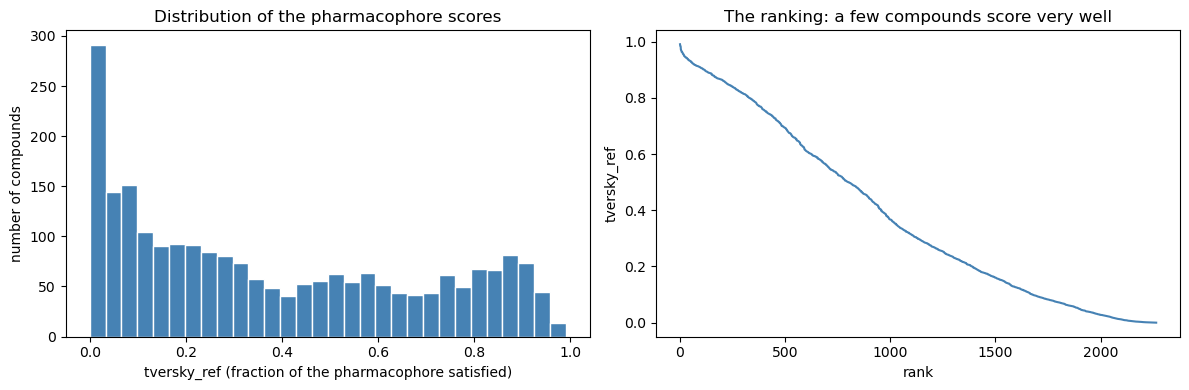

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(scores, bins=30, color="steelblue", edgecolor="white")
ax[0].set_xlabel("tversky_ref (fraction of the pharmacophore satisfied)")
ax[0].set_ylabel("number of compounds")
ax[0].set_title("Distribution of the pharmacophore scores")

ax[1].plot(np.arange(1, n_hits + 1), scores, color="steelblue")
ax[1].set_xlabel("rank")
ax[1].set_ylabel("tversky_ref")
ax[1].set_title("The ranking: a few compounds score very well")

plt.tight_layout()
plt.show()

The histogram shows what a pharmacophore screen really produces: not a yes/no classification but a **ranked list**, with a long tail of mediocre matches and a small head of molecules that reproduce the three-finger motif almost perfectly.

The sensible way to define a refined compound collection is therefore a **score cut-off**, and the validation tells us where to put it: the known inhibitors that satisfied the complete model reached a `tversky_ref` of about 0.95. We keep the compounds that reach the same level.

In [24]:
SCORE_CUTOFF = 0.90

refined_hits = [(index, result) for index, result in ranked_hits if result.tversky_ref >= SCORE_CUTOFF]

print(f"compounds with tversky_ref >= {SCORE_CUTOFF}: {len(refined_hits)}")
print(f"that is {100.0 * len(refined_hits) / n_before:.2f} % of the {n_before} compounds we started from")

# Collect the refined collection in a DataFrame
rows = []
for index, result in refined_hits:
    mol = database_mols[index]
    mol_2d = Chem.RemoveHs(mol)
    rows.append({
        "compound_id": mol.GetProp("_Name") if mol.HasProp("_Name") else f"mol_{index}",
        "smiles": Chem.MolToSmiles(mol_2d),
        "tversky_ref": round(result.tversky_ref, 3),
        "tanimoto": round(result.tanimoto, 3),
        "overlap_volume": round(result.overlap_volume, 2),
        "mw": round(Descriptors.MolWt(mol_2d), 1),
        "clogp": round(Descriptors.MolLogP(mol_2d), 2),
    })

refined_df = pd.DataFrame(rows)
refined_df.head(20)

compounds with tversky_ref >= 0.9: 116
that is 2.18 % of the 5326 compounds we started from


,compound_id,smiles,tversky_ref,tanimoto,overlap_volume,mw,clogp
0,BDE_33629388,COCCn1cnc2cc(C(=O)N3CCCC[C@H]3c3nc(N)ncc3-c3cc...,0.991,0.479,79.92,491.0,4.74
1,BAS_02324569,CCOC(=O)c1c(NC(=O)CSc2nnc3c4c5c(sc4ncn23)CCCC5...,0.985,0.400,79.45,529.7,4.70
2,ASN_06917332,O=C(C(c1ccccc1)c1ccccc1)N1CCC(c2nc(O)c3nnn(Cc4...,0.984,0.409,79.42,539.0,5.17
3,ASN_06916583,Cc1ccc(C)c(Cn2nnc3c(O)nc(C4CCN(C(=O)c5ccccc5[N...,0.982,0.369,79.26,487.5,3.52
4,ASN_06919429,Cc1cccc(C(=O)N2CCC[C@H](c3nc(O)c4nnn(Cc5ccccc5...,0.972,0.466,78.40,462.9,3.96
5,ASN_10813939,O=C(N1CCC(c2nc(O)c3nnn(Cc4ccc(F)cc4)c3n2)CC1)C...,0.969,0.400,78.18,535.0,4.99
6,ASN_10813931,O=C(N1CCC(c2nc(O)c3nnn(Cc4c(Cl)cccc4Cl)c3n2)CC...,0.969,0.400,78.16,585.9,6.15
7,ASN_06538606,COc1ccc(S(=O)(=O)N2CCCN(c3nc4cc(C)c(C)cc4cc3C#...,0.967,0.495,77.99,450.6,3.63
8,ASN_06917829,O=C(C1CCC1)N1CCC(c2nc(O)c3nnn(Cc4ccc(Cl)cc4Cl)...,0.963,0.460,77.70,461.4,3.79
9,BAS_01098826,CCCCOc1ccc(N2C(=O)[C@H]3[C@H]4c5ccccc5[C@](C(=...,0.963,0.530,77.69,467.5,4.50


### The top-ranked compounds

Now look at the molecules themselves. This is the part of a virtual screen that cannot be automated: a human being has to decide whether the hits make chemical sense.

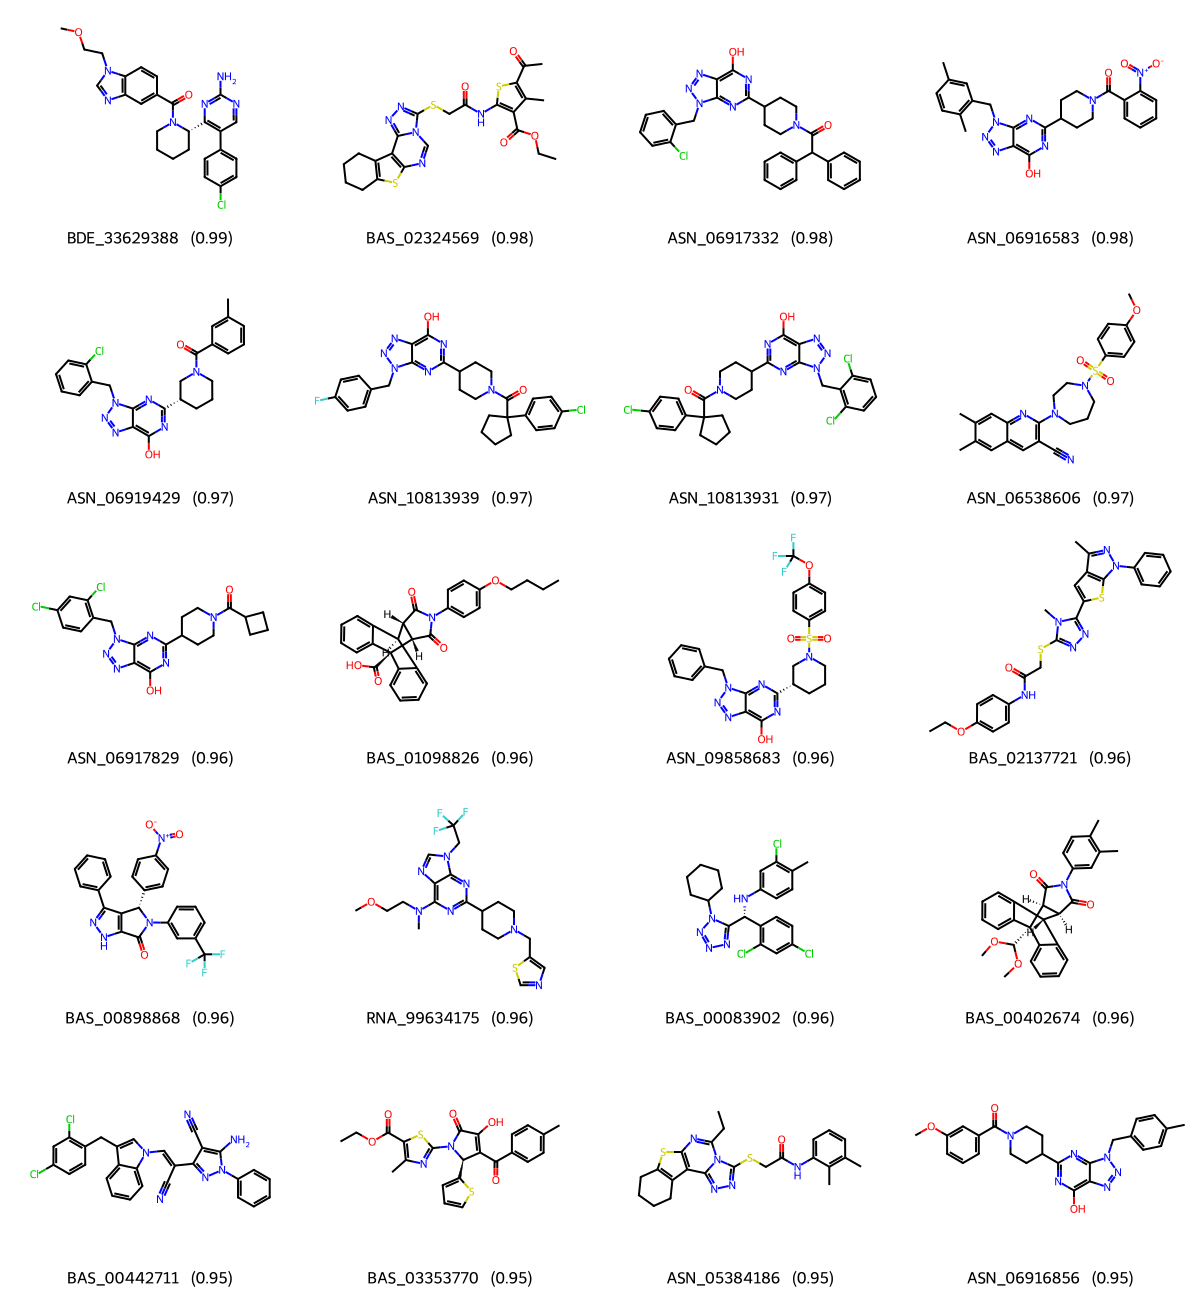

In [25]:
N_SHOW = 20

top_mols = []
top_legends = []
for index, result in refined_hits[:N_SHOW]:
    mol_2d = Chem.RemoveHs(database_mols[index])
    Chem.rdDepictor.Compute2DCoords(mol_2d)
    top_mols.append(mol_2d)
    name = database_mols[index].GetProp("_Name") if database_mols[index].HasProp("_Name") else f"mol_{index}"
    top_legends.append(f"{name}  ({result.tversky_ref:.2f})")

Draw.MolsToGridImage(top_mols, legends=top_legends, molsPerRow=4, subImgSize=(300, 260))

**Question 7.** Inspect these structures.

- Do they share an obvious common substructure, or are the scaffolds different?
- Can you identify, in each of them, the three hydrophobic groups that the pharmacophore matched?
- Look at the molecular weights in the table above. They sit just below the five known inhibitors, which weigh 555 to 660 Da, and not one hit is lighter than 451 Da. That lower bound is not something the pharmacophore decided: it is the molecular-weight filter you applied in notebook 4. Which compounds can this screen therefore never return, however well they might have matched the three fingers? And is a lighter, more flexible molecule that satisfies a 3-point pharmacophore as convincing as a heavier, rigid one? (Think about how many conformations each of them can adopt, and about how much of the pocket they can fill.)

### The best hit in the binding site

Because the alignment is performed in the coordinate frame of the query, and the query was derived from 1YCR, the aligned conformations that PyPharao returns are **in the frame of the MDM2 structure**. We can therefore drop the best hit straight into the pocket and look at it - next to the p53 helix it is supposed to displace.

In [26]:
best_index, best_result = refined_hits[0]
best_name = database_mols[best_index].GetProp("_Name")
print(f"best hit: {best_name}   tversky_ref = {best_result.tversky_ref:.3f}")

# result.aligned_mol is a copy of the molecule, transformed into the query frame
aligned_block = Chem.MolToPDBBlock(Chem.RemoveHs(best_result.aligned_mol))

view = py3Dmol.view(width=800, height=500)

# model 0: MDM2 and the p53 helix
view.addModel(pdb_1ycr, "pdb")
view.setStyle({"chain": "A"}, {"cartoon": {"color": "lightgray"}})
view.addSurface(py3Dmol.VDW, {"opacity": 0.55, "color": "lightgray"}, {"chain": "A"})
view.setStyle({"chain": "B"}, {"cartoon": {"color": "red"}})
view.addStyle({"chain": "B", "resi": [19, 23, 26]},
              {"stick": {"colorscheme": "redCarbon", "radius": 0.20}})

# model 1: the pharmacophore
with open("scratch/mdm2_three_finger.pdb") as f:
    view.addModel(f.read(), "pdb")
view.setStyle({"model": 1, "elem": "C"},
              {"sphere": {"radius": 1.4, "color": "orange", "opacity": 0.5}})

# model 2: the aligned hit
view.addModel(aligned_block, "pdb")
view.setStyle({"model": 2}, {"stick": {"colorscheme": "cyanCarbon", "radius": 0.20}})

view.zoomTo({"model": 1})
view.setBackgroundColor("white")
view.show()

best hit: BDE_33629388   tversky_ref = 0.991


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

The hit (cyan) should be sitting in the same cleft as the p53 side chains (red), with its hydrophobic groups on the orange spheres. Rotate the view: does the molecule stay inside the pocket, or does part of it stick out into the solvent - or into the protein? This simple visual check is often enough to discard a hit.

We also write the aligned top hits to an SDF file, so that they can be inspected in PyMOL. Passing `pharmacophore=` writes the query as the first record of the file, so the pharmacophore and the hits can be displayed together.

In [27]:
n_written = write_hits_sdf(refined_hits[:50], "scratch/pharmacophore_top_hits.sdf",
                           pharmacophore=three_finger)
print(f"{n_written} records written to scratch/pharmacophore_top_hits.sdf "
      f"(record 1 is the pharmacophore, the rest are aligned hits)")

# And the refined collection as a table, for use in a later notebook or in Excel
refined_df.to_csv("scratch/pharmacophore_refined_collection.csv", index=False)
print(f"{len(refined_df)} compounds written to scratch/pharmacophore_refined_collection.csv")

51 records written to scratch/pharmacophore_top_hits.sdf (record 1 is the pharmacophore, the rest are aligned hits)
116 compounds written to scratch/pharmacophore_refined_collection.csv


### Was one conformation per molecule enough?

As promised, we now check the price of the single-conformation shortcut. We take the top of the ranking, generate a proper conformer ensemble for each of those molecules, and screen again.

In [28]:
N_RESCREEN = 50
N_RESCREEN_CONFS = 25

rescreen_input = []
for index, _ in refined_hits[:N_RESCREEN]:
    mol_3d = generate_conformers(Chem.RemoveHs(database_mols[index]), N_RESCREEN_CONFS, RANDOM_SEED)
    if mol_3d is None:
        continue                                    # skip molecules that fail to embed
    rescreen_input.append((index, mol_3d))

rescreen_hits = searcher.screen(rescreen_input, conformations="all", keep="best",
                                metric="tversky_ref", n_jobs=0, progress=False)

single = {index: result.tversky_ref for index, result in refined_hits[:N_RESCREEN]}
ensemble = {index: result.tversky_ref for index, result in rescreen_hits}

comparison = pd.DataFrame({
    "one stored conformation": [single[i] for i in ensemble],
    f"best of {N_RESCREEN_CONFS} conformations": [ensemble[i] for i in ensemble],
}).round(3)

print(f"{len(ensemble)} of the top {N_RESCREEN} compounds re-screened with a conformer ensemble\n")
print(comparison.describe().round(3).loc[["mean", "min", "max"]])

45 of the top 50 compounds re-screened with a conformer ensemble

      one stored conformation  best of 25 conformations
mean                    0.952                     0.907
min                     0.931                     0.440
max                     0.991                     0.996


Compare the mean scores. They are of the same order, so the single-conformation screen is a usable first filter - but the minimum shows that for individual molecules the score can drop a long way. That is not a contradiction: a freshly generated ensemble of 25 conformers need not contain the particular shape that the one stored conformation happened to have. A pharmacophore score is therefore always a property of *the conformer ensemble you generated*, not an absolute property of the molecule.

And notice what we did **not** test. We only re-screened compounds that already scored well. Compounds that were rejected in stage 1 because their single stored conformation was unsuitable stay invisible to us, and we have no way of counting them. **That is the honest limitation of this workflow**, and the reason why a serious campaign generates a conformer ensemble for the whole database.

## 13. Combining the methods: the screening funnel

It is worth stepping back and looking at what the four notebooks have done together. Every step used a different kind of information, and every step removed compounds.

In [29]:
funnel = pd.DataFrame([
    ("Asinex vendor library",                      646891, "-"),
    ("property filter + similarity + ML (notebook 4)", n_before, "properties and 2D fingerprints, ligand-based"),
    ("three-finger pharmacophore (this notebook)", n_hits,   "3D features, structure-based"),
    (f"pharmacophore score >= {SCORE_CUTOFF}",     len(refined_df), "3D features, structure-based"),
], columns=["step", "compounds", "information used"])

funnel["% of library"] = (100.0 * funnel["compounds"] / 646891).round(3)
funnel

,step,compounds,information used,% of library
0,Asinex vendor library,646891,-,100.000
1,property filter + similarity + ML (notebook 4),5326,"properties and 2D fingerprints, ligand-based",0.823
2,three-finger pharmacophore (this notebook),2264,"3D features, structure-based",0.350
3,pharmacophore score >= 0.9,116,"3D features, structure-based",0.018


Two points are worth making about this table.

First, the two filters are **complementary, not redundant**. The machine-learning models of notebooks 3 and 4 learned from the 2D fingerprints of known MDM2 binders: they recognise molecules that *look like* the compounds in ChEMBL. The pharmacophore knows nothing about known binders - it was derived from the protein structure - and asks whether a molecule can reproduce the *interaction pattern* of p53. A compound that survives both filters is supported by two independent arguments.

Second, and more sobering: a reduction to a fraction of a percent of the library sounds impressive, but **none of these compounds has been shown to bind MDM2**. A pharmacophore hit is a hypothesis that says: *this molecule could, in one of its conformations, place three hydrophobic groups the way p53 does*. It says nothing about desolvation, entropy, the protein moving, competing binding modes, selectivity, solubility or metabolic stability. The usual next steps would be:

- **docking** of the refined collection into 1YCR or into a higher-resolution MDM2-inhibitor structure, to get a pose and an interaction-based score;
- **molecular dynamics** or free-energy calculations on a handful of the best poses;
- visual inspection and triage by a medicinal chemist;
- purchase and **experimental testing**, typically in a fluorescence-polarisation or HTRF assay that measures displacement of a p53 peptide from MDM2.

Only the last step produces evidence.

## 14. Exercises

Work through at least two of these.

1. **Tolerance.** Re-run the screen with `EPSILON = 0.5` (the strict setting) and with `EPSILON = 0.2`. How does the number of hits change, and how does the overlap with the previous hit list change? Which setting would you defend?

2. **Partial matching.** Run the screen with `min_matches=2`. How many compounds now pass? Is the top of the ranking still the same? What does this tell you about using recall as your only criterion?

3. **A four-point pharmacophore.** Add the Trp23 `HDON` feature (the variable `hdon_point`) to a copy of `three_finger`, and screen with `min_matches=3`, i.e. three of the four features. Which of the five known inhibitors now match, and does the hit list become more interesting? Note that `HDON` in the query matches only a donor in the molecule - look up `PointType.HACC_OR_HDON` in the PyPharao documentation and think about whether that would be a better choice.

4. **Conformational sampling.** Take the one known inhibitor that the strict model missed and that has three hydrophobic features, generate 500 instead of 50 conformers, and screen again with the strict settings. Does more sampling rescue it? What does your answer say about screening a database with one conformation per molecule?

5. **Scoring metric.** Re-rank the screening results with `key="tanimoto"` instead of `"tversky_ref"` (use `sort_match_results`). Which kinds of molecule move to the top, and why? Which metric is appropriate for a 3-point query?

## 15. Take-home messages

1. A **pharmacophore** is an abstract 3D arrangement of chemical features - not atoms, not a substructure. That abstraction is what lets it jump between chemical series.
2. Because it is a 3D model, matching it requires **3D conformations**. Conformer generation is part of the method, not a technicality, and insufficient sampling causes false negatives.
3. The p53-MDM2 interaction is carried by **three hydrophobic hot spots - Phe19, Trp23 and Leu26** - plus one hydrogen bond from the Trp23 indole N-H. This is the structural basis of the "three-finger pharmacophore" of MDM2 inhibitors.
4. A pharmacophore derived directly from a **peptide** is geometrically more demanding than a small molecule can satisfy: our strict model retrieved only 2 of 5 known inhibitors. **Always validate against known actives.**
5. There are three standard reasons for a validation failure, and we met all three: an over-strict **geometry**, limits of **feature perception** (navtemadlin has only two perceivable hydrophobic features), and **conformational sampling**.
6. Making a model more tolerant raises recall and lowers precision. There is no setting that is right in the abstract - it depends on what you will do with the hit list.
7. Ligand-based (fingerprints, ML) and structure-based (pharmacophore, docking) methods use **different information** and are best used in series, as a funnel.
8. **A pharmacophore hit is not a binder.** It is a hypothesis to be tested by docking, simulation and ultimately experiment.

## 16. References

**The p53-MDM2 interaction and its structural basis**

1. Kussie, P.H.; Gorina, S.; Marechal, V.; Elenbaas, B.; Moreau, J.; Levine, A.J.; Pavletich, N.P. (1996) Structure of the MDM2 oncoprotein bound to the p53 tumor suppressor transactivation domain. *Science* **274**, 948-953. <a href="https://doi.org/10.1126/science.274.5289.948" target="_blank">doi:10.1126/science.274.5289.948</a> - PDB <a href="https://www.rcsb.org/structure/1YCR" target="_blank">1YCR</a>, the structure used in this notebook.
2. Vassilev, L.T.; Vu, B.T.; Graves, B.; Carvajal, D.; Podlaski, F.; Filipovic, Z.; Kong, N.; Kammlott, U.; Lukacs, C.; Klein, C.; Fotouhi, N.; Liu, E.A. (2004) In vivo activation of the p53 pathway by small-molecule antagonists of MDM2. *Science* **303**, 844-848. <a href="https://doi.org/10.1126/science.1092472" target="_blank">doi:10.1126/science.1092472</a> - the nutlins.
3. Popowicz, G.M.; Doemling, A.; Holak, T.A. (2011) The structure-based design of Mdm2/Mdmx-p53 inhibitors gets serious. *Angew. Chem. Int. Ed.* **50**, 2680-2688. <a href="https://doi.org/10.1002/anie.201003863" target="_blank">doi:10.1002/anie.201003863</a>
4. Estrada-Ortiz, N.; Neochoritis, C.G.; Doemling, A. (2016) How to design a successful p53-MDM2/X interaction inhibitor: a thorough overview based on crystal structures. *ChemMedChem* **11**, 757-772. <a href="https://doi.org/10.1002/cmdc.201500487" target="_blank">doi:10.1002/cmdc.201500487</a> - a survey of the binding modes of all major inhibitor classes.
5. Wang, S.; Zhao, Y.; Aguilar, A.; Bernard, D.; Yang, C.-Y. (2017) Targeting the MDM2-p53 protein-protein interaction for new cancer therapy: progress and challenges. *Cold Spring Harb. Perspect. Med.* **7**, a026245. <a href="https://doi.org/10.1101/cshperspect.a026245" target="_blank">doi:10.1101/cshperspect.a026245</a>
6. Angulo, J.; Goffin, S.A.; Gandhi, D.; Searcey, M.; Howell, L.A. (2016) Unveiling the "three-finger pharmacophore" required for p53-MDM2 inhibition by saturation-transfer difference (STD) NMR initial growth-rates approach. *Chemistry* **22**, 5858-5862. <a href="https://doi.org/10.1002/chem.201600114" target="_blank">doi:10.1002/chem.201600114</a>

**The five validation compounds**

7. Anil, B.; Riedinger, C.; Endicott, J.A.; Noble, M.E.M. (2013) The structure of an MDM2-Nutlin-3a complex solved by the use of a validated MDM2 surface-entropy reduction mutant. *Acta Crystallogr. D* **69**, 1358-1366. <a href="https://doi.org/10.1107/S0907444913004459" target="_blank">doi:10.1107/S0907444913004459</a> - PDB <a href="https://www.rcsb.org/structure/4HG7" target="_blank">4HG7</a>, used here for the bound conformation of nutlin-3a.
8. Wang, S.; Sun, W.; Zhao, Y.; McEachern, D.; Meaux, I.; Barriere, C.; Stuckey, J.A.; Meagher, J.L.; Bai, L.; Liu, L. *et al.* (2014) SAR405838: an optimized inhibitor of MDM2-p53 interaction that induces complete and durable tumor regression. *Cancer Res.* **74**, 5855-5865. <a href="https://doi.org/10.1158/0008-5472.CAN-14-0799" target="_blank">doi:10.1158/0008-5472.CAN-14-0799</a> - PDB <a href="https://www.rcsb.org/structure/5TRF" target="_blank">5TRF</a>.
9. Holzer, P.; Masuya, K.; Furet, P.; Kallen, J.; Valat-Stachyra, T.; Ferretti, S.; Berghausen, J.; Bouisset-Leonard, M.; Buschmann, N.; Pissot-Soldermann, C. *et al.* (2015) Discovery of a dihydroisoquinolinone derivative (NVP-CGM097): a highly potent and selective MDM2 inhibitor undergoing phase 1 clinical trials. *J. Med. Chem.* **58**, 6348-6358. <a href="https://doi.org/10.1021/acs.jmedchem.5b00810" target="_blank">doi:10.1021/acs.jmedchem.5b00810</a> - PDB <a href="https://www.rcsb.org/structure/4ZYF" target="_blank">4ZYF</a>.
10. Jeay, S.; Ferretti, S.; Holzer, P.; Fuchs, J.; Chapeau, E.A.; Wartmann, M.; Sterker, D.; Romanet, V.; Murakami, M.; Kerr, G. *et al.* (2018) Dose and schedule determine distinct molecular mechanisms underlying the efficacy of the p53-MDM2 inhibitor HDM201. *Cancer Res.* **78**, 6257-6267. <a href="https://doi.org/10.1158/0008-5472.CAN-18-0338" target="_blank">doi:10.1158/0008-5472.CAN-18-0338</a> - siremadlin; PDB <a href="https://www.rcsb.org/structure/5OC8" target="_blank">5OC8</a>.
11. Sun, D.; Li, Z.; Rew, Y.; Gribble, M.; Bartberger, M.D.; Beck, H.P.; Canon, J.; Chen, A.; Chen, X.; Chow, D. *et al.* (2014) Discovery of AMG 232, a potent, selective, and orally bioavailable MDM2-p53 inhibitor in clinical development. *J. Med. Chem.* **57**, 1454-1472. <a href="https://doi.org/10.1021/jm401753e" target="_blank">doi:10.1021/jm401753e</a> - navtemadlin (AMG 232); the piperidinone series is represented in the PDB by <a href="https://www.rcsb.org/structure/4OAS" target="_blank">4OAS</a> and <a href="https://www.rcsb.org/structure/4ERF" target="_blank">4ERF</a>.

**Pharmacophores and the software used**

12. Wermuth, C.G.; Ganellin, C.R.; Lindberg, P.; Mitscher, L.A. (1998) Glossary of terms used in medicinal chemistry (IUPAC recommendations 1998). *Pure Appl. Chem.* **70**, 1129-1143. <a href="https://doi.org/10.1351/pac199870051129" target="_blank">doi:10.1351/pac199870051129</a> - the definition of a pharmacophore quoted in section 1.
13. Taminau, J.; Thijs, G.; De Winter, H. (2008) Pharao: pharmacophore alignment and optimization. *J. Mol. Graph. Model.* **27**, 161-169. <a href="https://doi.org/10.1016/j.jmgm.2008.04.003" target="_blank">doi:10.1016/j.jmgm.2008.04.003</a> - **the reference to cite when you use PyPharao.**
14. PyPharao, the Python implementation of Pharao: <a href="https://github.com/silicos-it/PyPharao" target="_blank">https://github.com/silicos-it/PyPharao</a>
15. Wolber, G.; Langer, T. (2005) LigandScout: 3-D pharmacophores derived from protein-bound ligands and their use as virtual screening filters. *J. Chem. Inf. Model.* **45**, 160-169. <a href="https://doi.org/10.1021/ci049885e" target="_blank">doi:10.1021/ci049885e</a>
16. Yang, S.-Y. (2010) Pharmacophore modeling and applications in drug discovery: challenges and recent advances. *Drug Discov. Today* **15**, 444-450. <a href="https://doi.org/10.1016/j.drudis.2010.03.013" target="_blank">doi:10.1016/j.drudis.2010.03.013</a>

## Finished?

Then you have completed the computational drug-design workflow of this course: from the protein structure (notebook 1) and the representation of small molecules (notebook 2), through machine-learning models (notebook 3) and a focussed compound database (notebook 4), to a structure-based 3D filter and a ranked, refined candidate collection (this notebook).

The files produced here - `scratch/pharmacophore_top_hits.sdf` and `scratch/pharmacophore_refined_collection.csv` - are the deliverable of a virtual-screening campaign: the compounds you would actually order and test.